# **The Broke Student’s Breakaway—Optimizing Fixed-Gear Performance on a Limited Time and Budget Notebook**
***
**Author:** Dhan Tamparong  
**Course:** Undergraduate Data Science Project  
**Date:** February 2026

## **📖 Project Overview**
This notebook analyzes personal cycling telemetry from Strava and Apple Watch–derived heart-rate zones to evaluate whether a flexible structured regimen (Zone 2 + intervals) is associated with measurable performance gains on a fixed-gear setup.

Because the historical dataset (W0) does not contain standardized time-trial tests, baseline comparisons use matched-distance rides (20–23 km) and regression controls (distance, elevation) to reduce confounding.

## **🎯 Notebook Goals**
1. **Ingest & Clean:** Load merged ride logs, standardize timestamps, and convert HR-zone time (HH:MM:SS → minutes).
2. **Engineer Features:** Create interpretable training metrics without power data:
   - `avg_cadence_rpm` (physics-based cadence estimate)
   - `efficiency_factor` = speed / HR (training rides only)
   - `hi_minutes` = Z4 + Z5 minutes (high-intensity dose)
   - `hi_share` = (Z4 + Z5) / total zone minutes (high-intensity density)
   - `days_since_last_ride` (freshness proxy)
3. **EDA & Visualization:** Compare speed distributions, track weekly discipline via zone composition, and relate intensity to speed.
4. **Statistical Inference:** Test training-phase effects and predictor relationships using appropriate methods (Welch t-test, nonparametric checks, ANOVA/Kruskal, correlation, robust regression).
5. **Hypothesis Validation:** Evaluate training effect, intensity-performance association, and exploratory equipment (cleats) effects with controlled comparisons.

## **📌 Key Notes**
- HR-zone metrics exist only for training weeks (W1–W9), so intensity analyses are performed on training rides only.
- Results are interpreted with emphasis on effect sizes, confidence intervals, and sensitivity checks due to real-world confounding (route, elevation, weather, traffic).

---

# **1. Setup & Ingestion**

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# For regression inference + robust SE
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [90]:
url = "https://raw.githubusercontent.com/dhan-t/CCDATSCL_COM222_PROJECT/refs/heads/main/Dataset%20Collection/DATA%20SCIENCE_MERGED.csv"

df = pd.read_csv(url)
df

,id,name,distance,moving_time,elapsed_time,total_elevation_gain,start_date,average_speed,max_speed,average_temp,...,avg_hr,max_hr,min_hr,cleats,week,z1_time,z2_time,z3_time,z4_time,z5_time
0,1.660000e+10,Afternoon Ride,21.39,64.88,4046,51.0,2025-11-23T06:24:44Z,19.78,39.82,30.0,...,0,0,0,0,0,0:00:00,0:00:00,0:00:00,0:00:00,0:00:00
1,1.650000e+10,Afternoon Ride,21.37,65.55,4081,103.4,2025-11-23T06:24:12Z,19.56,41.33,NaN,...,0,0,0,0,0,0:00:00,0:00:00,0:00:00,0:00:00,0:00:00
2,1.650000e+10,Afternoon Bypass Laps,23.56,56.03,3396,39.0,2025-11-22T08:53:59Z,25.23,41.47,27.0,...,0,0,0,0,0,0:00:00,0:00:00,0:00:00,0:00:00,0:00:00
3,1.650000e+10,Morning Indang x3 Ride,60.61,168.77,11460,436.0,2025-11-19T22:51:51Z,21.55,45.36,27.0,...,0,0,0,0,0,0:00:00,0:00:00,0:00:00,0:00:00,0:00:00
4,1.650000e+10,Afternoon Indang x2 Training,50.56,138.62,10828,356.0,2025-11-18T06:02:46Z,21.88,48.53,29.0,...,0,0,0,0,0,0:00:00,0:00:00,0:00:00,0:00:00,0:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,1.730000e+10,DS Long ride (W9),40.94,116.05,7431,220.0,2026-02-06T07:02:54Z,21.17,44.57,26.0,...,139,184,83,1,9,0:48:39,0:42:24,0:22:09,0:02:24,0:00:15
261,1.730000e+10,DS Zone 2 (W9),41.05,110.63,6661,252.0,2026-02-05T08:07:55Z,22.26,52.85,27.0,...,146,193,88,1,9,0:15:38,1:04:24,0:25:36,0:03:27,0:01:36
262,1.730000e+10,DS INTERVAL (W9),11.51,26.52,1958,40.0,2026-02-01T23:49:25Z,26.04,42.26,26.0,...,159,182,93,1,9,0:03:17,0:04:51,0:04:38,0:09:44,0:04:03
263,1.730000e+10,DS Free ride (W9),8.34,23.12,1822,38.0,2026-02-01T08:57:04Z,21.64,45.58,27.0,...,147,197,105,1,9,0:07:54,0:04:18,0:04:38,0:04:31,0:02:27


In [91]:
df.shape

(265, 23)

# **2. Preprocessing & Cleaning**

In [92]:
# Date Conversion & Sorting
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')

# Filtering invalid data
df = df.dropna(subset=['start_date', 'distance'])

# Filter out Test rides (<2km)
df = df[df['distance'] >= 2.0].copy()

# Sort chronologically to ensure "Freshness" diff() works
df = df.sort_values('start_date').reset_index(drop=True)

# Zone Time Conversion (String "HH:MM:SS" -> Float Minutes)
zone_cols_time = ['z1_time', 'z2_time', 'z3_time', 'z4_time', 'z5_time']
for col in zone_cols_time:
    new_col = col.replace('_time', '_minutes')
    df[new_col] = pd.to_timedelta(df[col].astype(str), errors='coerce').dt.total_seconds() / 60

# **3. Feature Engineering**

In [93]:
# Constants (Fixed Gear 49x17, 700x28c)
GEAR_RATIO = 49 / 17
TIRE_CIRCUMFERENCE = 2.136

# 1. Cadence (RPM) - Vectorized Physics Calc
df['avg_cadence_rpm'] = (df['average_speed'] * 1000) / (GEAR_RATIO * TIRE_CIRCUMFERENCE * 60)

# 2. Efficiency Factor (Speed / HR)  [Experimental rides only because avg_hr is 0 in historical]
df['efficiency_factor'] = df['average_speed'] / df['avg_hr'].replace(0, np.nan)

# 3. High-Intensity Minutes (Z4+Z5 Dose) - HR-zone based
df['hi_minutes'] = df['z4_minutes'] + df['z5_minutes']

# 4. Total Zone Time (Total HR-Zone Minutes)
zone_cols_min = ['z1_minutes','z2_minutes','z3_minutes','z4_minutes','z5_minutes']
df['total_zone_minutes'] = df[zone_cols_min].sum(axis=1)

# 5. High-Intensity Share (Z4+Z5 Density)
df['hi_share'] = (df['z4_minutes'] + df['z5_minutes']) / df['total_zone_minutes'].replace(0, np.nan)

# 6. Freshness (Days Since Last Ride)
df['days_since_last_ride'] = df['start_date'].diff().dt.total_seconds() / 86400

# 7. Training Phase Label
df['phase'] = df['week'].apply(lambda x: 'Historical (W0)' if x == 0 else 'Training (W1-W9)')

In [94]:
print("\nSample Engineered Features:")
print(df[['avg_cadence_rpm', 'efficiency_factor', 'hi_minutes', 'total_zone_minutes', 'hi_share','days_since_last_ride','phase']].tail())

print(f"\nNew Shape: {df.shape}")


Sample Engineered Features:
     avg_cadence_rpm  efficiency_factor  hi_minutes  total_zone_minutes  \
258        58.581110           0.147211    6.966667           23.800000   
259        70.492242           0.163774   13.783333           26.550000   
260        60.259497           0.152466    5.050000          110.683333   
261        57.308785           0.152302    2.650000          115.850000   
262        81.780746           0.174624   37.583333           40.250000   

     hi_share  days_since_last_ride             phase  
258  0.292717              4.394132  Training (W1-W9)  
259  0.519146              0.619687  Training (W1-W9)  
260  0.045626              3.346181  Training (W1-W9)  
261  0.022874              0.954850  Training (W1-W9)  
262  0.933747              1.036343  Training (W1-W9)  

New Shape: (263, 35)


In [95]:
df.columns

Index(['id', 'name', 'distance', 'moving_time', 'elapsed_time',
       'total_elevation_gain', 'start_date', 'average_speed', 'max_speed',
       'average_temp', 'elev_high', 'elev_low', 'pr_count', 'avg_hr', 'max_hr',
       'min_hr', 'cleats', 'week', 'z1_time', 'z2_time', 'z3_time', 'z4_time',
       'z5_time', 'z1_minutes', 'z2_minutes', 'z3_minutes', 'z4_minutes',
       'z5_minutes', 'avg_cadence_rpm', 'efficiency_factor', 'hi_minutes',
       'total_zone_minutes', 'hi_share', 'days_since_last_ride', 'phase'],
      dtype='object')

# **4. Exploratory Data Analysis**

/tmp/ipython-input-546403673.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


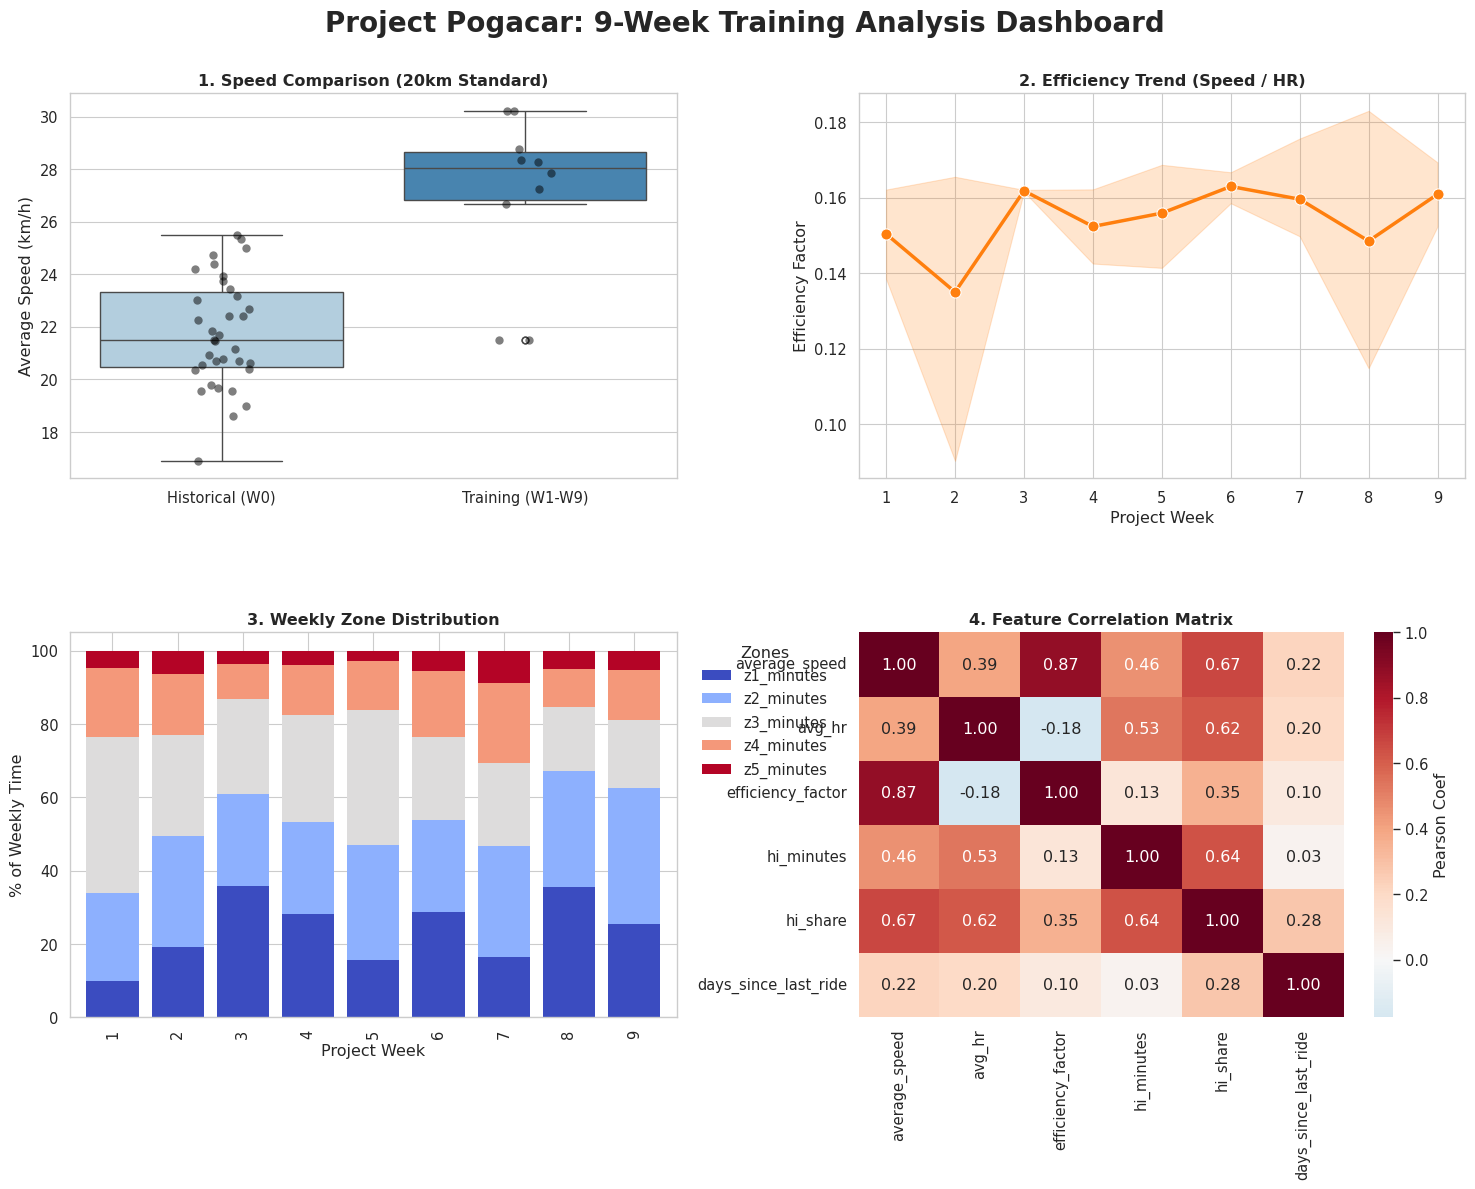

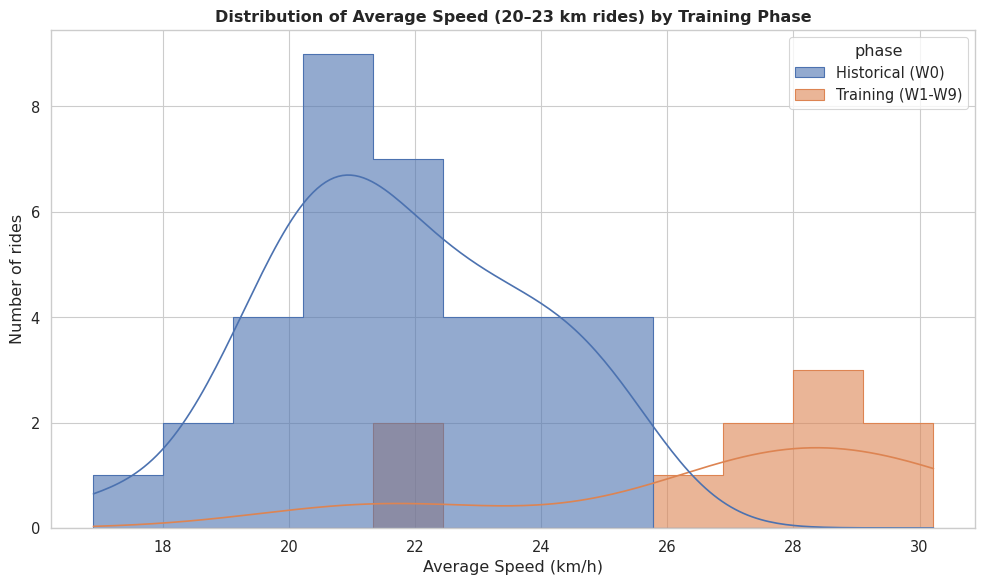

In [96]:
# Set Theme
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Create a Figure with a 2x2 Grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3) # Adjust spacing between charts

# ---------------------------------------------------------
# CHART A: COMPARE GROUPS (Box Plot) - Top Left [0,0]
# ---------------------------------------------------------
df_tt = df[(df['distance'] >= 20) & (df['distance'] <= 23)].copy()

sns.boxplot(
    data=df_tt, x='phase', y='average_speed', ax=axes[0, 0],
    palette="Blues", order=['Historical (W0)', 'Training (W1-W9)']
)
sns.stripplot(
    data=df_tt, x='phase', y='average_speed', ax=axes[0, 0],
    color='black', alpha=0.5, jitter=True, size=6
)

axes[0, 0].set_title('1. Speed Comparison (20km Standard)', fontweight='bold')
axes[0, 0].set_ylabel('Average Speed (km/h)')
axes[0, 0].set_xlabel('')

# ---------------------------------------------------------
# CHART B: TRENDS (Efficiency) - Top Right [0,1]
# ---------------------------------------------------------
sns.lineplot(
    data=df, x='week', y='efficiency_factor', ax=axes[0, 1],
    marker='o', color='tab:orange', linewidth=2.5, markersize=8
)

axes[0, 1].set_title('2. Efficiency Trend (Speed / HR)', fontweight='bold')
axes[0, 1].set_ylabel('Efficiency Factor')
axes[0, 1].set_xlabel('Project Week')

# ---------------------------------------------------------
# CHART C: DISCIPLINE (Zone Distribution) - Bottom Left [1,0]
# ---------------------------------------------------------
df_train = df[df['phase'] == 'Training (W1-W9)'].copy()
zone_cols_min = ['z1_minutes','z2_minutes','z3_minutes','z4_minutes','z5_minutes']
weekly_zones = df_train.groupby('week')[zone_cols_min].sum()

# Normalize to 100%
weekly_zones_pct = weekly_zones.div(weekly_zones.sum(axis=1), axis=0) * 100

weekly_zones_pct.plot(
    kind='bar', stacked=True, width=0.8, ax=axes[1, 0],
    colormap='coolwarm', edgecolor='none'
)

axes[1, 0].set_title('3. Weekly Zone Distribution', fontweight='bold')
axes[1, 0].set_ylabel('% of Weekly Time')
axes[1, 0].set_xlabel('Project Week')
axes[1, 0].legend(title='Zones', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# ---------------------------------------------------------
# CHART D: SANITY CHECK (Correlation) - Bottom Right [1,1]
# ---------------------------------------------------------
corr_cols = ['average_speed', 'avg_hr', 'efficiency_factor', 'hi_minutes', 'hi_share', 'days_since_last_ride']
corr_matrix = df_train[corr_cols].corr()

sns.heatmap(
    corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
    ax=axes[1, 1], cbar_kws={'label': 'Pearson Coef'}
)

axes[1, 1].set_title('4. Feature Correlation Matrix', fontweight='bold')

# Final Layout Polish
plt.suptitle("Project Pogacar: 9-Week Training Analysis Dashboard", fontsize=20, fontweight='bold', y=0.95)
plt.savefig('combined_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_std,
    x="average_speed",
    hue="phase",
    bins=12,
    stat="count",
    common_norm=False,
    element="step",
    alpha=0.6,
    kde=True
)
plt.title("Distribution of Average Speed (20–23 km rides) by Training Phase", fontweight="bold")
plt.xlabel("Average Speed (km/h)")
plt.ylabel("Number of rides")
plt.tight_layout()
plt.savefig("chart_avg_speed_histogram_20_23km.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [97]:
# For specific charts

# A. Classify Ride Type (Training Only)
def classify_ride(row):
    name = str(row.get('name', '')).upper()
    if 'TT TEST' in name or 'TIME TRIAL' in name: return 'TT Test'
    elif 'INTERVAL' in name or 'INT' in name: return 'Intervals'
    elif 'ZONE 2' in name or ' Z2' in name: return 'Zone 2'
    return 'Other'

df['ride_type'] = df.apply(classify_ride, axis=1)

# B. Time of Day
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce', utc=True)
# Convert to local time (assuming UTC+8 for PH/Manila)
df['start_hour'] = (df['start_date'].dt.hour + 8) % 24
df['time_of_day'] = np.where(df['start_hour'] < 12, 'Morning', 'Afternoon')

# C. Pedals
if 'cleats' in df.columns:
    df['pedals'] = df['cleats'].map({0: 'Flat Pedals', 1: 'Cleats'}).fillna('Unknown')
else:
    df['pedals'] = 'Unknown'

# D. Weekly Z2 Volume (Merge back to main df)
df_train = df[df['phase'] == 'Training (W1-W9)'].copy()
weekly_z2 = df_train.groupby('week')['z2_minutes'].sum().reset_index().rename(columns={'z2_minutes': 'weekly_z2_vol'})
df_train = df_train.merge(weekly_z2, on='week', how='left')

# Filter Main Rides for clean plotting
main_df = df_train[df_train['ride_type'].isin(['TT Test', 'Intervals', 'Zone 2'])].copy()


/tmp/ipython-input-2554449320.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=z2_df, x='pedals', y='average_speed', ax=axes[0,1], size=8, palette='Set2', jitter=True)


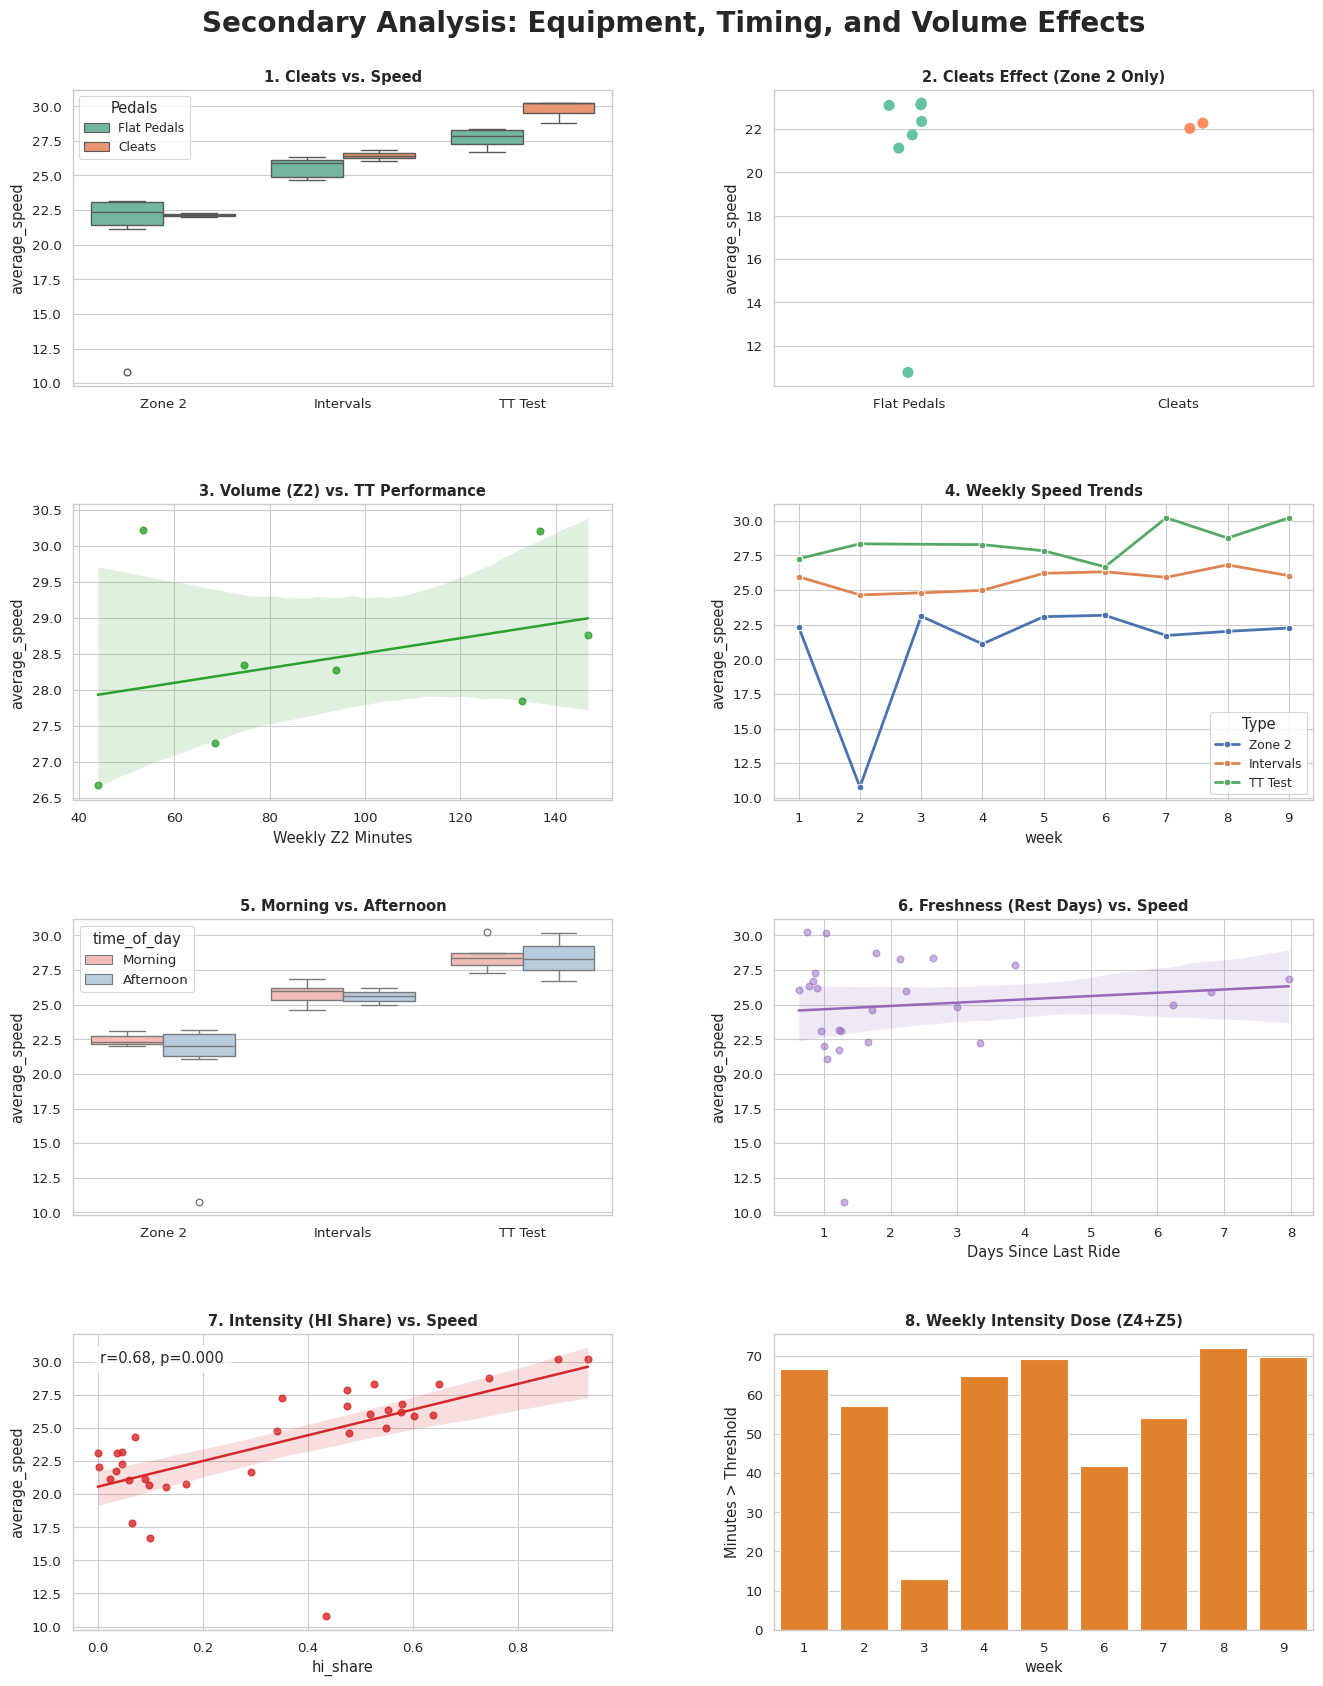

In [98]:
# Set Theme
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# CHANGE: 4 Rows, 2 Columns (Fits 8 charts exactly)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ---------------------------------------------------------
# ROW 1
# ---------------------------------------------------------
# Chart 1: Cleats vs Speed (Boxplot) [0,0]
sns.boxplot(data=main_df, x='ride_type', y='average_speed', hue='pedals', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('1. Cleats vs. Speed', fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].legend(title='Pedals', loc='upper left', bbox_to_anchor=(0,1), fontsize='small')

# Chart 2: Cleats in Zone 2 Only (Strip) [0,1]
z2_df = main_df[main_df['ride_type'] == 'Zone 2']
sns.stripplot(data=z2_df, x='pedals', y='average_speed', ax=axes[0,1], size=8, palette='Set2', jitter=True)
axes[0,1].set_title('2. Cleats Effect (Zone 2 Only)', fontweight='bold')
axes[0,1].set_xlabel('')

# ---------------------------------------------------------
# ROW 2
# ---------------------------------------------------------
# Chart 3: Weekly Z2 Volume vs TT Speed (Reg) [1,0]
tt_data = df_train[df_train['ride_type'] == 'TT Test']
sns.regplot(data=tt_data, x='weekly_z2_vol', y='average_speed', ax=axes[1,0], color='tab:green')
axes[1,0].set_title('3. Volume (Z2) vs. TT Performance', fontweight='bold')
axes[1,0].set_xlabel('Weekly Z2 Minutes')

# Chart 4: Speed Trend by Ride Type (Line) [1,1]
sns.lineplot(data=main_df, x='week', y='average_speed', hue='ride_type', marker='o', ax=axes[1,1], linewidth=2)
axes[1,1].set_title('4. Weekly Speed Trends', fontweight='bold')
axes[1,1].legend(title='Type', fontsize='small')

# ---------------------------------------------------------
# ROW 3
# ---------------------------------------------------------
# Chart 5: Time of Day Effect (Box) [2,0]
sns.boxplot(data=main_df, x='ride_type', y='average_speed', hue='time_of_day', ax=axes[2,0], palette='Pastel1')
axes[2,0].set_title('5. Morning vs. Afternoon', fontweight='bold')
axes[2,0].set_xlabel('')

# Chart 6: Rest Days vs Speed (Scatter) [2,1]
sns.regplot(data=main_df, x='days_since_last_ride', y='average_speed', ax=axes[2,1], scatter_kws={'alpha':0.5}, color='tab:purple')
axes[2,1].set_title('6. Freshness (Rest Days) vs. Speed', fontweight='bold')
axes[2,1].set_xlabel('Days Since Last Ride')

# ---------------------------------------------------------
# ROW 4
# ---------------------------------------------------------
# Chart 7: Intensity Density (HI Share) vs Speed [3,0]
sns.regplot(data=df_train, x='hi_share', y='average_speed', ax=axes[3,0], color='tab:red')
# Add Correlation Stats
r, p = stats.pearsonr(df_train['hi_share'].fillna(0), df_train['average_speed'])
axes[3,0].text(0.05, 0.9, f'r={r:.2f}, p={p:.3f}', transform=axes[3,0].transAxes, bbox=dict(facecolor='white', alpha=0.8))
axes[3,0].set_title('7. Intensity (HI Share) vs. Speed', fontweight='bold')

# Chart 8: Weekly High Intensity Dose (Bar) [3,1]
weekly_hi = df_train.groupby('week')['hi_minutes'].sum().reset_index()
sns.barplot(data=weekly_hi, x='week', y='hi_minutes', ax=axes[3,1], color='tab:orange')
axes[3,1].set_title('8. Weekly Intensity Dose (Z4+Z5)', fontweight='bold')
axes[3,1].set_ylabel('Minutes > Threshold')

# Final Polish
plt.suptitle("Secondary Analysis: Equipment, Timing, and Volume Effects", fontsize=20, fontweight='bold', y=0.92)
plt.savefig('secondary_dashboard_8charts.png', dpi=300, bbox_inches='tight')
plt.show()

In [99]:
# ----------------------------
# 1) Ensure required columns exist
# ----------------------------
required = ["week", "average_speed", "avg_hr"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

# ----------------------------
# 2) Coerce numeric types
# ----------------------------
for c in ["average_speed", "avg_hr", "hi_share", "hi_minutes"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# ----------------------------
# 3) Training-only subset (W1–W9)
#    Handles week as "W1".."W9" or integers 1..9
# ----------------------------
week_str = df["week"].astype(str).str.upper().str.replace("W", "", regex=False)
df["week_num"] = pd.to_numeric(week_str, errors="coerce")

df_train = df.loc[df["week_num"].between(1, 9, inclusive="both")].copy()

# ----------------------------
# 4) If hi_minutes or hi_share aren't present, compute them (fallback)
#    Requires z4_minutes and z5_minutes (and optionally total_zone_minutes)
# ----------------------------
if "hi_minutes" not in df_train.columns:
    if {"z4_minutes", "z5_minutes"}.issubset(df_train.columns):
        df_train["hi_minutes"] = pd.to_numeric(df_train["z4_minutes"], errors="coerce") + pd.to_numeric(df_train["z5_minutes"], errors="coerce")
    else:
        raise ValueError("hi_minutes missing and cannot be computed (need z4_minutes and z5_minutes).")

if "hi_share" not in df_train.columns:
    if "total_zone_minutes" in df_train.columns and "hi_minutes" in df_train.columns:
        df_train["hi_share"] = df_train["hi_minutes"] / pd.to_numeric(df_train["total_zone_minutes"], errors="coerce")
    elif {"z1_minutes","z2_minutes","z3_minutes","z4_minutes","z5_minutes"}.issubset(df_train.columns):
        total_zone = sum(pd.to_numeric(df_train[z], errors="coerce") for z in ["z1_minutes","z2_minutes","z3_minutes","z4_minutes","z5_minutes"])
        df_train["hi_share"] = df_train["hi_minutes"] / total_zone
    else:
        raise ValueError("hi_share missing and cannot be computed (need total_zone_minutes or z1..z5 minutes).")

# ----------------------------
# 5) Compute efficiency_factor (km/h per bpm)
#    Avoid divide-by-zero by treating 0 HR as missing
# ----------------------------
df_train["avg_hr"] = df_train["avg_hr"].replace(0, np.nan)
df_train["efficiency_factor"] = df_train["average_speed"] / df_train["avg_hr"]

# ----------------------------
# 6) Option B table: Training structure summary (Mean/Median/SD)
# ----------------------------
metrics = [
    ("Average speed (km/h)", "average_speed"),
    ("HI share (Z4+Z5 / total)", "hi_share"),
    ("HI minutes (Z4+Z5)", "hi_minutes"),
    ("Average HR (bpm)", "avg_hr"),
    ("Efficiency factor (km/h per bpm)", "efficiency_factor"),
]

rows = []
for label, col in metrics:
    if col not in df_train.columns:
        continue
    series = df_train[col].dropna()
    rows.append([label, series.mean(), series.median(), series.std(ddof=1)])

training_table = pd.DataFrame(rows, columns=["Variable", "Mean", "Median", "SD"]).round(3)

print(f"Training Block Descriptive Statistics (W1–W9), n = {len(df_train)} rides")
display(training_table)

# ----------------------------
# 7) Optional exports for paper/Overleaf
# ----------------------------
training_table.to_csv("table_training_structure_W1_W9.csv", index=False)
training_table.to_latex("table_training_structure_W1_W9.tex", index=False)

Training Block Descriptive Statistics (W1–W9), n = 40 rides


,Variable,Mean,Median,SD
0,Average speed (km/h),23.301,23.095,4.130
1,HI share (Z4+Z5 / total),0.340,0.346,0.279
2,HI minutes (Z4+Z5),12.698,12.442,11.111
3,Average HR (bpm),155.457,153.000,13.312
4,Efficiency factor (km/h per bpm),0.154,0.156,0.024


# **5. Hypothesis Testing**

In [100]:
# H1 HELPER
def one_sided_from_two_sided_t(t_stat, p_two_sided, direction="greater"):
    if direction == "greater":
        return (p_two_sided / 2) if (t_stat > 0) else (1 - p_two_sided / 2)
    else:
        return (p_two_sided / 2) if (t_stat < 0) else (1 - p_two_sided / 2)

def hedges_g(x, y):
    x = x.dropna().astype(float)
    y = y.dropna().astype(float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    sx2, sy2 = x.var(ddof=1), y.var(ddof=1)
    sp = np.sqrt(((nx - 1)*sx2 + (ny - 1)*sy2) / (nx + ny - 2))
    if sp == 0:
        return np.nan
    d = (x.mean() - y.mean()) / sp
    # small-sample correction
    J = 1 - (3 / (4*(nx + ny) - 9))
    return d * J

def safe_col(df, col, default=np.nan):
    return df[col] if col in df.columns else default

# H2 HELPER
def parse_week_num(s):
    s = s.astype(str).str.upper().str.replace("W", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

def is_tt_name(name):
    n = str(name).upper()
    return ("TT TEST" in n) or ("TIME TRIAL" in n) or ("TT" in n)

def one_sided_p_from_t(t_val, p_two_sided):
    # Ha: beta > 0
    if np.isnan(t_val) or np.isnan(p_two_sided):
        return np.nan
    return (p_two_sided / 2) if (t_val > 0) else (1 - p_two_sided / 2)

In [101]:
# ============================================================
# H1) TRAINING EFFECT (ONE-WAY ANOVA)
# Ho: μ(W0) = μ(W1–W9)
# Ha: μ(W1–W8) > μ(W0)  (direction checked via means; ANOVA p is non-directional)
# ============================================================

print("\n" + "="*60)
print("H1. TRAINING EFFECT (ONE-WAY ANOVA): W1–W8 vs W0 (MATCHED 20–23 km)")
print("="*60)

# --- 1) Match distance band (fair proxy for the standardized test route) ---
df_band = df[(df["distance"].between(20, 23, inclusive="both"))].copy()

# --- 2) Robust week parsing (handles week as 0..9 OR 'W0'..'W9') ---
week_str = df_band["week"].astype(str).str.upper().str.replace("W", "", regex=False)
df_band["week_num"] = pd.to_numeric(week_str, errors="coerce")

# Keep only W0 and W1–W8
df_h1 = df_band[df_band["week_num"].isin([0,1,2,3,4,5,6,7,8,9])].copy()

# Phase labels
df_h1["phase"] = np.where(df_h1["week_num"] == 0, "Historical (W0)", "Training (W1–W8)")

# Clean: drop missing speeds
df_h1 = df_h1.dropna(subset=["average_speed"])

# --- 3) Descriptive stats (standard to report alongside ANOVA) ---
desc = (
    df_h1.groupby("phase")["average_speed"]
    .agg(n="size", mean="mean", sd="std", median="median")
    .round(3)
)
print("\nDescriptive statistics (average_speed, km/h):")
display(desc)

# --- 4) One-way ANOVA using statsmodels (gives a proper ANOVA table) ---
# Model: average_speed ~ phase (categorical)
model = smf.ols("average_speed ~ C(phase)", data=df_h1).fit()
aov = anova_lm(model, typ=2)

# Effect size: eta-squared = SS_between / SS_total
ss_between = aov.loc["C(phase)", "sum_sq"]
ss_within = aov.loc["Residual", "sum_sq"]
ss_total = ss_between + ss_within
eta_sq = ss_between / ss_total

# Pull standard reporting values
df_between = int(aov.loc["C(phase)", "df"])
df_within = int(aov.loc["Residual", "df"])
F = float(aov.loc["C(phase)", "F"])
p = float(aov.loc["C(phase)", "PR(>F)"])

print("\nOne-way ANOVA (average_speed ~ phase):")
display(aov.round(6))

print(f"\nANOVA result: F({df_between}, {df_within}) = {F:.4f}, p = {p:.4e}, eta² = {eta_sq:.3f}")

# --- 5) Directional conclusion (since your Ha is 'training is higher') ---
mean_hist = desc.loc["Historical (W0)", "mean"]
mean_train = desc.loc["Training (W1–W8)", "mean"]

if (p < 0.05) and (mean_train > mean_hist):
    print("✅ DECISION: Reject Ho. Training (W1–W8) has significantly higher average_speed than W0.")
elif (p < 0.05) and (mean_train <= mean_hist):
    print("⚠️ NOTE: ANOVA is significant, but training mean is not higher than historical mean (direction mismatch).")
else:
    print("❌ DECISION: Fail to reject Ho. No significant difference detected between W1–W8 and W0.")



H1. TRAINING EFFECT (ONE-WAY ANOVA): W1–W8 vs W0 (MATCHED 20–23 km)

Descriptive statistics (average_speed, km/h):


,n,mean,sd,median
phase,,,,
Historical (W0),35,21.772,2.076,21.49
Training (W1–W8),10,27.061,3.133,28.06



One-way ANOVA (average_speed ~ phase):


,sum_sq,df,F,PR(>F)
C(phase),217.595337,1.0,39.840037,0.0
Residual,234.854187,43.0,NaN,NaN



ANOVA result: F(1, 43) = 39.8400, p = 1.2858e-07, eta² = 0.481
✅ DECISION: Reject Ho. Training (W1–W8) has significantly higher average_speed than W0.


In [102]:
# ============================================================
# H2) INTENSITY PREDICTS TT SPEED (Ordinary Least Squares (OLS))
# Ho: beta_hi = 0
# Ha: beta_hi > 0
# ============================================================

# ---------- 1) Training subset (W1–W9 only) ----------
df_train = df.copy()
df_train["week_num"] = parse_week_num(df_train["week"])

df_train = df_train[df_train["week_num"].between(1, 9, inclusive="both")].copy()

# Ensure numeric zone cols exist (needed to compute HI minutes)
zone_cols = ["z1_minutes","z2_minutes","z3_minutes","z4_minutes","z5_minutes"]
missing_zone = [c for c in zone_cols if c not in df_train.columns]
if missing_zone:
    raise ValueError(f"Missing zone columns needed for HI minutes: {missing_zone}")

for c in zone_cols + ["average_speed", "days_since_last_ride"]:
    if c in df_train.columns:
        df_train[c] = pd.to_numeric(df_train[c], errors="coerce")

# Identify TT rides
if "name" not in df_train.columns:
    raise ValueError("Missing 'name' column; cannot identify TT rides.")
df_train["is_tt"] = df_train["name"].apply(is_tt_name)

tt = df_train[df_train["is_tt"]].copy()
non_tt = df_train[~df_train["is_tt"]].copy()

print(f"Training rides in W1–W8: n = {len(df_train)}")
print(f"TT tests found (W1–W8): n = {len(tt)}")

if len(tt) < 5:
    print("⚠️ WARNING: Very small TT count. Regression will be underpowered; interpret cautiously.")

# ---------- 2) Build weekly predictors (exclude TT ride itself) ----------
non_tt["hi_minutes"] = non_tt["z4_minutes"] + non_tt["z5_minutes"]

weekly_inputs = (
    non_tt.groupby("week_num")
    .agg(
        weekly_hi_minutes=("hi_minutes", "sum"),
        weekly_z2_minutes=("z2_minutes", "sum"),
        weekly_rides=("hi_minutes", "size"),
    )
    .reset_index()
)

# ---------- 3) Build weekly TT outcome ----------
weekly_tt = (
    tt.groupby("week_num")
    .agg(
        tt_speed=("average_speed", "mean"),
        tt_rest_days=("days_since_last_ride", "mean"),
        tt_count=("average_speed", "size"),
    )
    .reset_index()
)

weekly = pd.merge(weekly_tt, weekly_inputs, on="week_num", how="left")

# Keep only usable rows
weekly = weekly.dropna(subset=["tt_speed", "weekly_hi_minutes"])

print(f"\nWeekly rows usable (weeks with TT + HI data): n = {len(weekly)}")
display(weekly.sort_values("week_num"))

# ---------- 4) Descriptives (standard) ----------
print("\nDescriptive statistics (weekly):")
print(f"TT speed: mean = {weekly['tt_speed'].mean():.3f}, SD = {weekly['tt_speed'].std(ddof=1):.3f}")
print(f"Weekly HI minutes: mean = {weekly['weekly_hi_minutes'].mean():.3f}, SD = {weekly['weekly_hi_minutes'].std(ddof=1):.3f}")

# ---------- 5) Primary test: Simple OLS regression (best with small n) ----------
# Model: tt_speed ~ weekly_hi_minutes
m1 = smf.ols("tt_speed ~ weekly_hi_minutes", data=weekly).fit(cov_type="HC3")

coef = m1.params["weekly_hi_minutes"]
se = m1.bse["weekly_hi_minutes"]
tval = m1.tvalues["weekly_hi_minutes"]
p_two = m1.pvalues["weekly_hi_minutes"]
p_one = one_sided_p_from_t(tval, p_two)

print("\nModel (Primary): tt_speed ~ weekly_hi_minutes  [HC3 robust SE]")
print(f"n = {int(m1.nobs)} | R² = {m1.rsquared:.3f} | Adj R² = {m1.rsquared_adj:.3f}")
print(f"F = {m1.fvalue:.3f} | Prob(F) = {m1.f_pvalue:.4e}")

print("\nCoefficient (weekly_hi_minutes):")
print(f"beta = {coef:.6f} | SE = {se:.6f} | t = {tval:.3f} | p(two-sided) = {p_two:.4e} | p(one-sided, Ha>0) = {p_one:.4e}")

if (p_one < 0.05) and (coef > 0):
    print("✅ DECISION: Reject Ho. Higher weekly HI minutes significantly predict higher TT speed.")
else:
    print("❌ DECISION: Fail to reject Ho. No significant evidence that weekly HI minutes predict TT speed.")

Training rides in W1–W8: n = 40
TT tests found (W1–W8): n = 8

Weekly rows usable (weeks with TT + HI data): n = 8


,week_num,tt_speed,tt_rest_days,tt_count,weekly_hi_minutes,weekly_z2_minutes,weekly_rides
0,1,27.26,0.871829,1,50.516667,66.516667,4
1,2,28.34,2.628831,1,34.700000,73.533333,3
2,4,28.28,2.135289,1,37.116667,89.166667,4
3,5,27.84,3.857523,1,48.366667,129.983333,4
4,6,26.68,0.837407,1,20.066667,40.716667,3
5,7,30.22,0.743738,1,18.883333,52.483333,2
6,8,28.76,1.774398,1,40.850000,145.716667,5
7,9,30.21,1.036343,1,32.083333,136.233333,5



Descriptive statistics (weekly):
TT speed: mean = 28.449, SD = 1.270
Weekly HI minutes: mean = 35.323, SD = 11.641

Model (Primary): tt_speed ~ weekly_hi_minutes  [HC3 robust SE]
n = 8 | R² = 0.098 | Adj R² = -0.053
F = 0.231 | Prob(F) = 6.4781e-01

Coefficient (weekly_hi_minutes):
beta = -0.034108 | SE = 0.070966 | t = -0.481 | p(two-sided) = 6.3079e-01 | p(one-sided, Ha>0) = 6.8461e-01
❌ DECISION: Fail to reject Ho. No significant evidence that weekly HI minutes predict TT speed.


In [103]:
# ============================================================
# H2 — COMPRESSED TABLE OUTPUTS
# ============================================================

def parse_week_num(s):
    s = s.astype(str).str.upper().str.replace("W", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

def is_tt_name(name):
    n = str(name).upper()
    return ("TT TEST" in n) or ("TIME TRIAL" in n) or ("TT" in n)

if "weekly" not in globals():
    df_train = df.copy()
    df_train["week_num"] = parse_week_num(df_train["week"])
    df_train = df_train[df_train["week_num"].between(1, 9, inclusive="both")].copy()

    zone_cols = ["z1_minutes","z2_minutes","z3_minutes","z4_minutes","z5_minutes"]
    for c in zone_cols + ["average_speed","days_since_last_ride"]:
        if c in df_train.columns:
            df_train[c] = pd.to_numeric(df_train[c], errors="coerce")

    df_train["is_tt"] = df_train["name"].apply(is_tt_name)
    tt = df_train[df_train["is_tt"]].copy()
    non_tt = df_train[~df_train["is_tt"]].copy()

    non_tt["hi_minutes"] = non_tt["z4_minutes"] + non_tt["z5_minutes"]

    weekly_inputs = (
        non_tt.groupby("week_num")
        .agg(
            weekly_hi_minutes=("hi_minutes", "sum"),
            weekly_z2_minutes=("z2_minutes", "sum"),
            weekly_rides=("hi_minutes", "size"),
        )
        .reset_index()
    )

    weekly_tt = (
        tt.groupby("week_num")
        .agg(
            tt_speed=("average_speed", "mean"),
            tt_rest_days=("days_since_last_ride", "mean"),
            tt_count=("average_speed", "size"),
        )
        .reset_index()
    )

    weekly = pd.merge(weekly_tt, weekly_inputs, on="week_num", how="left")
    weekly = weekly.dropna(subset=["tt_speed", "weekly_hi_minutes"]).sort_values("week_num")

# ---------- (A) Recommended: Summary table (no per-week rows) ----------
summary_tbl = pd.DataFrame({
    "Variable": ["TT speed (km/h)", "Weekly HI minutes (Z4+Z5)", "Rest days before TT"],
    "n": [
        weekly["tt_speed"].count(),
        weekly["weekly_hi_minutes"].count(),
        weekly["tt_rest_days"].count()
    ],
    "Mean": [
        weekly["tt_speed"].mean(),
        weekly["weekly_hi_minutes"].mean(),
        weekly["tt_rest_days"].mean()
    ],
    "SD": [
        weekly["tt_speed"].std(ddof=1),
        weekly["weekly_hi_minutes"].std(ddof=1),
        weekly["tt_rest_days"].std(ddof=1)
    ],
    "Min": [
        weekly["tt_speed"].min(),
        weekly["weekly_hi_minutes"].min(),
        weekly["tt_rest_days"].min()
    ],
    "Max": [
        weekly["tt_speed"].max(),
        weekly["weekly_hi_minutes"].max(),
        weekly["tt_rest_days"].max()
    ],
}).round(3)

print("\n--- H2 Summary (recommended for paper) ---")
display(summary_tbl)

# ---------- Model results table (single-row) ----------
m1 = smf.ols("tt_speed ~ weekly_hi_minutes", data=weekly).fit(cov_type="HC3")

model_tbl = pd.DataFrame([{
    "Model": "tt_speed ~ weekly_hi_minutes (HC3)",
    "n": int(m1.nobs),
    "beta_hi": float(m1.params["weekly_hi_minutes"]),
    "SE": float(m1.bse["weekly_hi_minutes"]),
    "t": float(m1.tvalues["weekly_hi_minutes"]),
    "p (two-sided)": float(m1.pvalues["weekly_hi_minutes"]),
    "R²": float(m1.rsquared),
    "Adj R²": float(m1.rsquared_adj),
    "Prob(F)": float(m1.f_pvalue) if m1.f_pvalue is not None else np.nan
}]).round(4)

print("\n--- H2 OLS Result (paper-ready) ---")
display(model_tbl)



--- H2 Summary (recommended for paper) ---


,Variable,n,Mean,SD,Min,Max
0,TT speed (km/h),8,28.449,1.270,26.680,30.220
1,Weekly HI minutes (Z4+Z5),8,35.323,11.641,18.883,50.517
2,Rest days before TT,8,1.736,1.101,0.744,3.858



--- H2 OLS Result (paper-ready) ---


,Model,n,beta_hi,SE,t,p (two-sided),R²,Adj R²,Prob(F)
0,tt_speed ~ weekly_hi_minutes (HC3),8,-0.0341,0.071,-0.4806,0.6308,0.0978,-0.0526,0.6478


In [105]:
# ============================================================
# H3 (TT-ONLY). CLEATS EFFECT ON TT TEST AVERAGE SPEED — ANOVA
# H0: μ_flats = μ_clipless
# Ha: μ_clipless > μ_flats
# ============================================================

# --- 1) Filter TT-only rides (training only) ---
dftt = df.copy()

# Build week_num robustly
if "week_num" in dftt.columns:
    dftt["week_num"] = pd.to_numeric(dftt["week_num"], errors="coerce")
elif "week" in dftt.columns:
    wk = dftt["week"].astype(str).str.upper().str.replace("W", "", regex=False)
    dftt["week_num"] = pd.to_numeric(wk, errors="coerce")
else:
    raise ValueError("Missing 'week' or 'week_num' column.")

# Training only (exclude historical week 0)
dftt = dftt[dftt["week_num"] > 0].copy()

# TT filter
if "name" not in dftt.columns:
    raise ValueError("Missing 'name' column; cannot identify TT rides.")
dftt = dftt[dftt["name"].apply(is_tt_name)].copy()

# Coerce numeric columns needed
for c in ["cleats", "average_speed"]:
    if c not in dftt.columns:
        raise ValueError(f"Missing required column: '{c}'")
    dftt[c] = pd.to_numeric(dftt[c], errors="coerce")

# Keep only valid cleats coding
dftt = dftt[dftt["cleats"].isin([0, 1])].copy()

print(f"TT TEST rides found (training only): n = {len(dftt)}")
counts = dftt["cleats"].value_counts().sort_index()
print(f"Cleats counts in TT rides: flats(0)={int(counts.get(0,0))}, clipless(1)={int(counts.get(1,0))}")

# --- 2) Descriptives (to check direction) ---
dfx = dftt.dropna(subset=["cleats", "average_speed"]).copy()
desc = (
    dfx.groupby("cleats")["average_speed"]
    .agg(n="count", mean="mean", sd="std", median="median")
    .round(3)
)
print("\nDescriptive statistics (TT-only) — average_speed (km/h):")
display(desc)

# Safety check: enough per group
n0 = int((dfx["cleats"] == 0).sum())
n1 = int((dfx["cleats"] == 1).sum())
if n0 < 2 or n1 < 2:
    print("⚠️ Not enough rides per group to run ANOVA reliably (need at least 2 per group).")
else:
    # --- 3) One-way ANOVA using OLS + anova_lm (standard) ---
    model = smf.ols("average_speed ~ C(cleats)", data=dfx).fit()
    aov = anova_lm(model, typ=2)

    # Effect size eta^2
    ss_eff = float(aov.loc["C(cleats)", "sum_sq"])
    ss_res = float(aov.loc["Residual", "sum_sq"])
    eta2 = ss_eff / (ss_eff + ss_res) if (ss_eff + ss_res) > 0 else np.nan

    df1 = int(aov.loc["C(cleats)", "df"])
    df2 = int(aov.loc["Residual", "df"])
    F = float(aov.loc["C(cleats)", "F"])
    p = float(aov.loc["C(cleats)", "PR(>F)"])

    print("\nOne-way ANOVA (average_speed ~ cleats):")
    display(aov)
    print(f"ANOVA result: F({df1}, {df2}) = {F:.4f}, p = {p:.4e}, eta² = {eta2:.3f}")

    # Direction check (not a directional p-value)
    mean0 = float(desc.loc[0, "mean"]) if 0 in desc.index else np.nan
    mean1 = float(desc.loc[1, "mean"]) if 1 in desc.index else np.nan

    if np.isfinite(mean0) and np.isfinite(mean1):
        direction = "clipless > flats" if mean1 > mean0 else "clipless ≤ flats"
        print(f"Direction check from means: {direction} (mean_flats={mean0:.3f}, mean_clipless={mean1:.3f})")

    # Decision statement consistent with your write-up style
    if p < 0.05 and mean1 > mean0:
        print("✅ DECISION (H3, avg speed): Reject H0. TT average_speed differs by pedal system and is higher with clipless.")
    elif p < 0.05:
        print("✅ DECISION (H3, avg speed): Reject H0. TT average_speed differs by pedal system, but not in the expected direction.")
    else:
        print("❌ DECISION (H3, avg speed): Fail to reject H0. No significant difference in TT average_speed by pedal system.")

TT TEST rides found (training only): n = 8
Cleats counts in TT rides: flats(0)=5, clipless(1)=3

Descriptive statistics (TT-only) — average_speed (km/h):


,n,mean,sd,median
cleats,,,,
0,5,27.68,0.707,27.84
1,3,29.73,0.840,30.21



One-way ANOVA (average_speed ~ cleats):


,sum_sq,df,F,PR(>F)
C(cleats),7.879687,1.0,13.86862,0.009805
Residual,3.409000,6.0,NaN,NaN


ANOVA result: F(1, 6) = 13.8686, p = 9.8052e-03, eta² = 0.698
Direction check from means: clipless > flats (mean_flats=27.680, mean_clipless=29.730)
✅ DECISION (H3, avg speed): Reject H0. TT average_speed differs by pedal system and is higher with clipless.
